# Context-free grammar approximation

PyFoma supports context-free grammar approximation with finite automata in the `cfg_approx` module. Example:

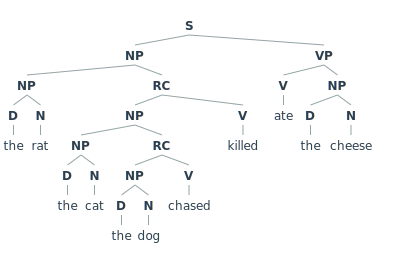

In [1]:
from pyfoma import cfg, cfg_approx
grammar = """
S -> NP VP
NP -> D N | NP RC | N 
RC -> NP V
VP -> V NP | V
D -> a | the
N -> rat | cat | dog | cheese
V -> chased | killed | ate
"""

sent = "the rat the cat the dog chased killed ate the cheese"
g = cfg_approx.CFG(grammar)
g.compile(levels = 3)
cfg.draw_tree(g.parse_ptb(sent)[0])

## Ambiguity

Even simple grammars can be ambiguous. Let’s look at prepositional phrase attachment ambiguity.

In [2]:
grammar_pp = """
S  -> NP VP
NP -> D N | NP PP | N
VP -> V NP | V NP PP | V
PP -> P NP
D  -> a | the
N  -> man | boy | telescope
V  -> saw
P  -> with
"""

sent = "the man saw the boy with the telescope"
g = cfg_approx.CFG(grammar_pp)
g.compile(levels=1)

ptbs = g.parse_ptb(sent)
len(ptbs), ptbs

(2,
 ['(S (NP (D the) (N man)) (VP (V saw) (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope)))))',
  '(S (NP (D the) (N man)) (VP (V saw) (NP (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope))))))'])

The parser returns trees in PTB format. Let's draw the two trees:

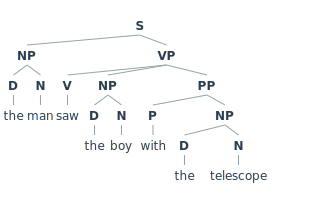

In [3]:
cfg.draw_tree(ptbs[0])

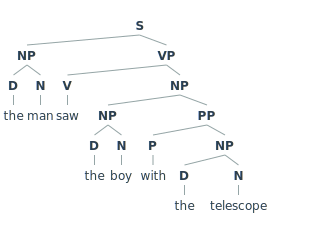

In [4]:
cfg.draw_tree(ptbs[1])

## Weighted parsing (PCFG-style costs)

If your grammar supports weights, you can attach them to rules. The parse result will still contain *all* parses, but you can request the best ones by total cost.

Example (weights are additive costs; lower = better):

In [5]:
grammar_pp = """
S  -> NP VP
NP -> D N | NP PP | N
VP -> V NP 1.0 | V NP PP 2.0 | V
PP -> P NP
D  -> a | the
N  -> man | boy | telescope
V  -> saw
P  -> with
"""

sent = "the man saw the boy with the telescope"

g = cfg_approx.CFG(grammar_pp)
g.compile(levels=1)

best = g.parse_ptb_with_cost(sent)
best

[(1.0,
  '(S (NP (D the) (N man)) (VP (V saw) (NP (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope))))))'),
 (2.0,
  '(S (NP (D the) (N man)) (VP (V saw) (NP (D the) (N boy)) (PP (P with) (NP (D the) (N telescope)))))')]

## How does it work?

The `cfg` module implements - with very minor changes - a finite-state CFG *subset approximation* method described by [Hulden & Silfverberg (2014)](https://web.archive.org/web/20210422143250id_/https://www.cs.uic.edu/pub/Isaim2014/WebPreferences/ISAIM2014_NLP_Hulden_Silfverberg.pdf).

### TL;DR

Instead of building a cubic-time parser (as in `cfg_parse`), we:

1. **Encode a subset of all derivation trees of a CFG as strings** over an auxiliary alphabet (brackets + markers + terminals + nonterminals).
2. Compile the grammar into a **finite automaton** `Gr` that accepts exactly those encoded derivation strings that are allowed by the approximation level.
3. For a sentence, build a simple **sentence automaton** that accepts the sentence’s words (and allows insertion of auxiliary encoding symbols).
4. **Intersect** the sentence automaton with `Gr`.
   The intersection automaton compactly represents *all parses* (ambiguity = multiple accepting paths).
5. Optionally, use weights and shortest paths / k-best extraction to pick the best parses.

For a fixed compiled grammar automaton `Gr`, intersecting it with a sentence automaton is essentially linear in sentence length (the product construction yields $|S|\cdot|Gr|$ states in the worst case).

The approximation is controlled by `levels`: higher values allow more center embedding and produce larger grammar automata.

The method `parse_ptb()` returns Penn Treebank style trees. `parse_pretty()` shows the native encoding used.

## More details

A finite-state automaton can encode, as a string, an arbitrarily large CFG-generated tree with labeled nodes of this shape:

```
        /\
       /\/\
      /\  /\
     /\    /\
    /\      /\
   .          .
  .            .
 .              .
/\              /\
```

Start at the bottom-left. __List the nodes of the left side in postorder__ (so children are listed before their parent), moving upward along the left spine. When you reach the top, __list the root__ and mark it as special. Then travel down the right side and __list the right side in preorder__ (so each parent is listed before its children).

The key consequence of this particular order is that __when a node is listed, its parent/children (or sibling subtree boundary) are nearby in the string__, so checking "this node obeys some CFG rule" reduces to checking a short local substring.

With this agreed-upon order of describing such a tree, we could encode a tree like this one:

```
                    S
                   / \
                  S   T
                 / \   \
                S   b   a
                |
                a
```

**Example (listing order).** For the tree above, the order is:

1. Left side postorder: `a, S, b, S`
2. Root marker: `( S )`
3. Right side preorder: `T, a`

Concatenated: `a S b S ( S ) T a`

### CFG-generated trees

Because rule well-formedness is visible in bounded windows of this encoding, we can build finite-state automata that check local constraints corresponding to each CFG rule, and then intersect them to obtain a single automaton that accepts exactly the well-formed encoded trees (up to the chosen approximation level).

In this encoding, the rule at a node shows up around the node’s own position. For example, the root rule `S -> S T` corresponds to the local window `... S ( S ) T ...`.

<span style='color: #000000; font-family: monospace; background-color: #F7F2F4;'>a S b </span><span style='color: #e74c3c; font-family: monospace; background-color: #F7F2F4;'>S ( S ) T</span><span style='color: #000000; font-family: monospace; background-color: #F7F2F4;'> a</span>

And we can tell that

<span style='color: #000000; font-family: monospace; background-color: #F7F2F4;'>a </span><span style='color: #e74c3c; font-family: monospace; background-color: #F7F2F4;'>S b S </span><span style='color: #000000; font-family: monospace; background-color: #F7F2F4;'>( S ) T a</span>

is OK if there is a rule `S -> S b`, etc. This is what's called a __locally testable language__: membership can be decided by checking which short substrings (up to a fixed length $k$) occur in the string.

That means that if we can create individual automata that check for correctness of substrings in the string representation (one for each rule), we can intersect those automata and produce a single automaton that checks that an arbitrarily large tree of this shape is correct as per some CFG.

$$CFG_{approx} = A_{rule_1} \cap \ldots \cap A_{rule_n}$$

## Parsing

To actually parse a string into a tree we simply create an automaton that contains the string we want to parse, ignoring nonterminals and other markup material that the representation may use, such as parentheses to mark the top of the tree, and intersect that with $CFG_{approx}$.

$$A_{parses} = A_{sentence} \cap CFG_{approx}$$

That this works is because of the very particular order we've decided to list the nodes - the listing order not only allows for local checking of correctness but it also preserves the linear order of terminals.

In the example above, to parse "aba" we would create the automaton:

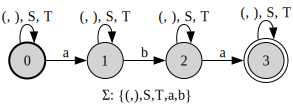

In [6]:
from pyfoma import FST
FST.re("$^ignore(a b a, S|T|'('|')')").view()

And intersect this with the tree checker for a CFG to get an automaton that contains all the valid parses. In practice, the parse-related methods in the `cfg` module of course do all this in the background for a grammar the user has provided.

The actual implementation uses a richer alphabet than __{S, T, (, )}__; the snippet above is just a toy illustration of the idea “accept the terminals, allow the encoding symbols to appear anywhere.”

## Actual encoding

The real implementation decorates the string further to make writing these local checks easy, and the parses more human-readable. Below we'll see an actual string that comes out of the parser, corresponding to:

```
                   S
                 /   \
                S     T
              /  \   / \
             S    b a   T
             |          |
             a          c
```

In [7]:
grammar = '''
S -> S T | S b | a
T -> a T | a | c
'''

gr0 = cfg_approx.CFG(grammar)
gr0.compile(levels=0)

sent = "a b a c"
# Native parse strings:
print("\n".join(gr0.parse_pretty(sent, n=10)))

[ a ] [ S -> a ] { b } [ S -> S b ] ( S -> S T ) [ T -> a T ] { a } [ T -> c ] [ c ]


Above you can see which string parts correspond to which parts in the tree, drawn below with the same numbering:

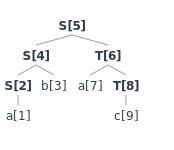

In [8]:
cfg.draw_tree("(S[5] (S[4] (S[2] a[1]) b[3]) (T[6] a[7] (T[8] c[9])))")

As you can see, the string representation contains actual rules for nonterminal nodes and terminal nodes are surrounded by `[ ]` or `{ }` - `{` `}` for inside nodes, `[` `]` otherwise.

### Non-binary trees

Additionally, if the top node of the tree isn't binary-branching, we list

* The leftmost branch in postorder
* The next branch in preorder
* Subsequent branches in preorder, preceded by the special symbol `^`

Example:

PTB encoding: ['(S (T a) (U (U b) b) (V (V c) c) (W d))'] 

Native encoding: ['[ a ] [ T -> a ] ( S -> T U V W ) [ U -> U b ] { < [ b ] ( U -> b ) > } [ b ] ^ [ V -> V c ] { < [ c ] ( V -> c ) > } [ c ] ^ [ W -> d ] [ d ]'] 



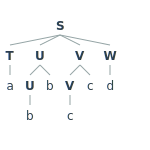

In [9]:
grammar = """
S -> T U V W
T -> a
U -> U b | b
V -> V c | c
W -> d
"""
sent = "a b b c c d"
g = cfg_approx.CFG(grammar)
g.compile(levels=1)

print("PTB encoding:", g.parse_ptb(sent), "\n")
print("Native encoding:", g.parse_pretty(sent), "\n")
cfg.draw_tree(g.parse_ptb(sent)[0])

## Approximation levels

Note that we're doing a very particular approximation of a CFG: we can parse arbitrarily long sentences, but can't parse strings that map to trees that aren't of the very shape described earlier (which may have more than two top branches, although only two are shown here):

```
        /\
       /\/\
      /\  /\
     /\    /\
    /\      /\
   .          .
  .            .
 .              .
/\              /\
```

So, for example, if a parse would yield a tree like
```
        /\
       /\/\
      /\  /\
           /\
          /\/\
          ^
         outside scope
```

then we can't parse it. However, once we have a basic tree acceptor, we can always recursively insert new tree acceptors into the string representation of that original tree acceptor, producing a better approximation. This is done by creating an FST that inserts copies of the original tree approximation at inside leaf nodes. Of course, the top of the inserted tree must match the nonterminal node where it is inserted. We're in effect __injecting new trees at all leaf positions in the original tree__. This creates a hierarchy of approximation levels. Level 0 is our first approximation, level 1 has new trees inserted at leaf nodes of level 0, and level 2 inserts yet more trees into level 1, etc. This is very closely related to the idea of [center-embedding](https://en.wikipedia.org/wiki/Center_embedding). Natural language does not tolerate many levels of center-embedded sentences, so we can potentially create a reasonable-sized automaton from a grammar for NLP purposes.

```
        /\
       /\/\
      /\  /\
     /\    /\
    /\      /\
   .       *  .   * insert tree here for level 1 (and at other leaf nodes)
  .            .
 .              .
/\              /\
```

Here's the automaton for level 0 approximation of the grammar

```
S -> S T | S b | a
T -> a T | a | c
```

As you can see, it is not very large at all, and in many cases, we can approximate CFG grammars with quite compact automata using this encoding.

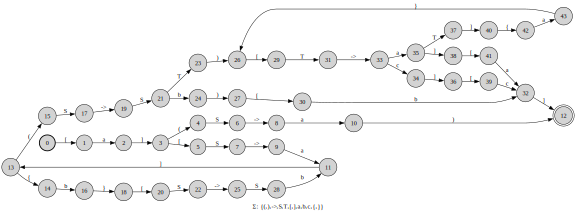

In [10]:
gr0.fsts['Gr'].view()

## Weight implementation

The weight implementation is quite simple. If the grammar is weighted, we first build an unweighted grammar automaton to the desired level of approximation, and then, as a postprocessing step, put weights on the substrings referring to rules in the tree. For example, whenever there is a `[ S -> S b ]` substring, we put a weight on the '->'-symbol, corresponding to the rules' weight. The weights are put in by simple rewrite rules. To weight this rule in a string representation of the parse tree by 2.0, we create the below FST, and compose it with the grammar to get a weighted grammar. That FST simply rewrites '->' as itself with a weight when surrounded by `[ S` to the left and `S b ]` to the right:

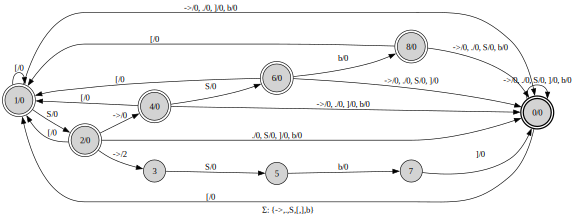

In [11]:
FST.re("$^rewrite('->':('->'<2.0>) / '[' S _ S b ']')").view()

## Fun fact

Even if you somehow know that a context-free grammar $G$ only generates a **regular** language, there is no general algorithm that will take any such $G$ and always produce an equivalent DFA. (This is a classic [undecidability result](https://math.stackexchange.com/questions/2187431/decidability-of-regularity-of-context-free-grammar); see e.g. Shallit's *[A Second Course in Formal Languages and Automata Theory](https://cs.uwaterloo.ca/~shallit/second.html)*.)

However, the above approximation method *can* give an exact DFA for **some** CFGs whose languages are regular, as follows:

* Take a grammar $G$.
* Build the approximation automata $Gr_k$ for $k=0,1,2,\dots$ (levels of approximation).
* If you ever reach a true fixed point $Gr_{k+1} \equiv Gr_k$, then the approximation will never change again.
* At that point, erase the auxiliary tree-encoding symbols by mapping them to ε, leaving a DFA over the terminal alphabet.
  *(In pyfoma, the compilation step already determinizes/minimizes the result.)*

Intuitively, this is expected to succeed for grammars whose derivations can be represented with __bounded nesting__ in this encoding (so the approximation stabilizes).

[Nederhof(2000)](https://aclanthology.org/J00-1003/) gives an example of a CFG that generates only a regular language, which we can test:
$$S~\rightarrow~A~a$$
$$A~\rightarrow~S~B~\mid~B~b$$
$$B~\rightarrow~B~c~\mid~d$$
We run the approximation until it stabilizes, and then remove auxiliary symbols, producing a minimal DFA for the language.

In [12]:
grammar = """
S -> A a
A -> S B | B b
B -> B c | d
"""
# Generates the language /d c* b a (d c* a)*/

prev_size = 0

for k, _ in enumerate(iter(lambda: 'hell', 'freezes over')):
    g = cfg_approx.CFG(grammar)
    g.compile(levels=k)
    size = len(g.fsts["Gr"]) # use size as proxy for equivalence...
    print(f"Grammar size at k={k}: {size}")

    if size == prev_size:
        print(f"Stabilized at k={k} (size {size})")
        break

    prev_size = size
    g_prev = g

Grammar size at k=0: 33
Grammar size at k=1: 78
Grammar size at k=2: 78
Stabilized at k=2 (size 78)


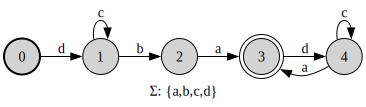

In [13]:
g.fsts["strings"].view()

# Ambiguous grammars

Highly ambiguous grammars create much larger approximations in terms of automaton size than unambiguous ones. Consider two grammars for the same language below; both define the language:

$$L = \Big\{a^n b^m \mid n,m \geq 0,\ n \leq 2m,\ m \leq 2n\Big\}$$


In [14]:
agrammar = """
S -> a S b | a a S b | a S b b | EPSILON
"""

ugrammar = """
S -> a S b | a a T b | a U b b | EPSILON
T -> a a T b | EPSILON
U -> a U b b | EPSILON
"""


ga = cfg_approx.CFG(agrammar)
ga.compile(levels = 3)
print("Number of states for ambiguous grammar:", len(ga.fsts["Gr"]))
print("Yield language size", len(ga.fsts["strings"]))

gu = cfg_approx.CFG(ugrammar)
gu.compile(levels= 3)
print("Number of states for unambiguous grammar:", len(gu.fsts["Gr"]))
print("Yield language size", len(gu.fsts["strings"]))

Number of states for ambiguous grammar: 5130
Yield language size 62
Number of states for unambiguous grammar: 886
Yield language size 53


## Speed

If your grammar is large, compiling it may be slow. [Foma](https://fomafst.github.io/) (written in pure C) can be used to compile much larger grammars (hundreds/thousands of rules) quickly with [this script](https://github.com/mhulden/foma/blob/master/foma/contrib/pcfg2foma.py). Foma FST files can also be imported to pyfoma with `FST.load_foma()`. If you just want to parse any grammar and draw trees, you can use the `cfg_parse` module which implements full cubic-time weighted and unweighted parsing with automata that encode the grammars as bracketed trees.

## References

Hulden, Mans and Miikka Silfverberg. *Finite-state subset approximation of phrase structure*. In International Symposium on Artificial Intelligence and Mathematics (ISAIM 2014), Fort Lauderdale, FL, USA, January 6-8, 2014. [[PDF]](https://web.archive.org/web/20210422143250id_/https://www.cs.uic.edu/pub/Isaim2014/WebPreferences/ISAIM2014_NLP_Hulden_Silfverberg.pdf)

Nederhof, Mark-Jan. 2000. *Practical Experiments with Regular Approximation of Context-Free Languages*. Computational Linguistics, 26(1):17–44. [[PDF]](https://aclanthology.org/J00-1003/)